# Vessel EDA

In [1]:
# Vessel EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

vessel_file = "C:/Users/sg-t1aidan/Desktop/Vessel Data/202301/vsl_position_20230101/vsl_position_20230101.csv"
df = pd.read_csv(vessel_file)
df.head()

,name,callSign,imoNumber,flag,length,type,grossTonnage,mmsiNumber,latitudeDegrees,longitudeDegrees,speedOverGround,speedOverWater,courseOverGround,courseOverWater,headingOverGround,headingOverWater,timeStamp
0,INDUS,9V8206,9537460,SG,88.0,TA,4262,563302000,1.197565,103.744866,0.000000,0.000000,1.55334,0.00,2.513274,143.9980,2023-01-01 05:36:01
1,STI VENERE,V7EM4,9681390,MH,183.0,TA,29785,538005495,1.215667,103.819464,0.257222,0.490604,3.75246,213.69,1.500983,85.9955,2023-01-01 05:36:01
2,BG,V7LO5,1007952,MH,42.0,YA,515,538071061,1.245320,103.840596,0.000000,0.000000,4.40870,0.00,1.570796,90.0000,2023-01-01 05:36:01
3,BE MINE,9HA2755,6239318,MT,36.0,YA,310,215606000,1.294957,103.760349,0.000000,0.000000,3.96539,0.00,3.665191,209.9980,2023-01-01 05:35:13
4,BLOOM,A8KC2,9365283,LR,177.0,CH,24112,636013026,1.263253,103.433407,0.000000,0.000000,5.46463,0.00,6.161012,352.9960,2023-01-01 05:35:13


In [6]:
df.shape

(19701668, 17)

In [3]:
df.columns

Index(['name', 'callSign', 'imoNumber', 'flag', 'length', 'type',
       'grossTonnage', 'mmsiNumber', 'latitudeDegrees', 'longitudeDegrees',
       'speedOverGround', 'speedOverWater', 'courseOverGround',
       'courseOverWater', 'headingOverGround', 'headingOverWater',
       'timeStamp'],
      dtype='object')

In [11]:
df.length.max()

np.float64(400.0)

In [2]:
# Convert timeStamp to datetime objects
df['timeStamp'] = pd.to_datetime(df['timeStamp'])

# Check for missing values (percentage)
missing_data = df.isnull().sum() / len(df) * 100

# Count unique vessels
unique_IMO_vessels = df['imoNumber'].nunique()
unique_MMSI_vessels = df['mmsiNumber'].nunique()

print(f"Unique IMO Vessels: {unique_IMO_vessels}")
print(f"Unique MMSI Vessels: {unique_MMSI_vessels}")
print(missing_data)

Unique IMO Vessels: 1478
Unique MMSI Vessels: 3125
name                  5.827806
callSign             17.201224
imoNumber             0.000000
flag                 19.674629
length                0.000000
type                 19.674629
grossTonnage          0.000000
mmsiNumber            8.479952
latitudeDegrees       0.000000
longitudeDegrees      0.000000
speedOverGround       0.000000
speedOverWater        0.000000
courseOverGround      0.000000
courseOverWater       0.000000
headingOverGround     0.000000
headingOverWater      0.000000
timeStamp             0.000000
dtype: float64


In [14]:
df = df.dropna(subset="type")

In [15]:
(df["imoNumber"] == 0).sum() / len(df) * 100

np.float64(39.70295166554)

In [16]:
df = df[df["imoNumber"] != 0]
df.shape

(9542272, 17)

In [18]:
9542272/19701668

0.48433828039331495

In [17]:
# identify dominant vessel types
df['type'].value_counts()[:10]


type
TA    4003991
TU    1429392
CS     879869
BC     679569
CH     443135
FR     346576
SV     330768
FB     329868
LP     165346
BA     146501
Name: count, dtype: int64

In [19]:
# 1. Map top 9 vessel type codes
vessel_type_map = {
    'TA': 'Tanker', # Vessels carrying liquids in bulk, such as crude oil, chemicals, or gas.
    'TU': 'Tug', # Powerful, small boats used to maneuver larger vessels in tight harbor spaces.
    'SV': 'Service Vessel', # Search and rescue, pilot boats, or supply ships for offshore platforms.
    'CS': 'Container Ship', # Large cargo vessels designed to carry standardized metal containers.
    'YA': 'Yacht', # Private recreational vessels
    'BC': 'Bulk Carrier', # Ships designed to carry unpackaged cargo like coal, grain, or ore.
    'WB': 'Workboat', # General utility vessels used for construction, maintenance, or diving support.
    'FB': 'Fishing Boat', # Vessels equipped for commercial fishing or fish processing at sea.
    'CH': 'Chemical Tanker' # Specialized tankers for transporting hazardous liquid chemicals.
}

# 2. Apply the mapping to create a new, readable column
df['vesselTypeName'] = df['type'].map(vessel_type_map)

# 3. Handle any codes not in our dictionary (drop na values)
df['vesselTypeName'] = df['vesselTypeName'].dropna()

# 4. Verify the results
print(df[['name', 'type', 'vesselTypeName']].head())

         name type   vesselTypeName
0       INDUS   TA           Tanker
1  STI VENERE   TA           Tanker
2          BG   YA            Yacht
3     BE MINE   YA            Yacht
4       BLOOM   CH  Chemical Tanker


In [28]:
df['flag'].value_counts()

flag
SG    4013843
PA     809236
ID     706760
LR     633078
MH     600516
       ...   
IR       4878
SE       3913
KW       2620
LK       1282
LI        167
Name: count, Length: 66, dtype: int64

In [29]:
df[df['flag'] == 'MY'].shape

(546680, 18)

In [23]:
df['flag'].unique()

array(['SG', 'MH', 'MT', 'LR', 'ID', 'PA', 'VN', 'KY', 'HK', 'GR', 'TR',
       '01', 'MN', 'SA', 'TH', 'KR', 'MY', 'AU', 'NO', 'LU', 'US', 'DK',
       'BE', 'TW', 'KI', 'JP', 'IN', 'CN', 'TZ', 'IT', 'BS', 'CY', 'NL',
       'EG', 'KN', 'PH', 'SL', 'TV', 'CM', 'ST', 'GA', 'BM', 'CK', 'PT',
       'PW', 'BZ', 'VC', 'SE', 'BR', 'DE', 'BD', 'FR', 'DM', 'AG', 'NU',
       'VU', 'DJ', 'IM', 'GI', 'MA', 'IR', 'QA', 'GB', 'KW', 'LK', 'LI'],
      dtype=object)

Most vessels are flagged under Singapore, Indonesia and Panama. Many also flagged under Panama as a flag of convenience. What about 01?

In [21]:
# Check the 'type' of vessels that have flag '01'
df[df['flag'] == '01']['type'].value_counts()

type
TU    49735
TA    10890
SV     8564
Name: count, dtype: int64

Primarily tugboats, tankers and surface vessels with unconfigured AIS codes.

In [30]:
# Summary statistics for size and speed
stats = df[['length', 'grossTonnage', 'speedOverGround']].describe()

# Categorize vessels by speed
df['status'] = df['speedOverGround'].apply(lambda x: 'At Anchor' if x < 0.5 else 'Under Way')

print(stats)
print(df['status'].value_counts())

             length  grossTonnage  speedOverGround
count  9.542272e+06  9.542272e+06     9.542272e+06
mean   1.279861e+02  2.306732e+04     9.898287e-01
std    8.942581e+01  3.932059e+04     3.664983e+00
min    0.000000e+00  1.000000e+01     0.000000e+00
25%    5.200000e+01  7.240000e+02     0.000000e+00
50%    1.030000e+02  5.036000e+03     0.000000e+00
75%    1.830000e+02  2.934400e+04     5.144440e-02
max    4.000000e+02  2.340060e+05     5.262770e+01
status
At Anchor    7881709
Under Way    1660563
Name: count, dtype: int64


In [31]:
df[df['status'] == "Under Way"]["vesselTypeName"].value_counts()[:10]

vesselTypeName
Tanker             561232
Container Ship     238003
Bulk Carrier       230157
Tug                221875
Fishing Boat       108818
Chemical Tanker     78010
Service Vessel      15958
Workboat             1929
Yacht                1138
Name: count, dtype: int64

## Predicting Vessel Length from Gross Tonnage
The AIS data used for simulating vessel movements between May and July 2023 has a corrupted length column. Since a vessel's overall length (LOA) is needed to determine how many tugs to assign, we fit a linear regression model to predict a vessel's LOA from its gross tonnage, depending on its type (container ship or tanker).

In [32]:
cs_df = df[df['type'].isin({"CS"})]

In [33]:
cs_df = cs_df[["imoNumber","type","length","grossTonnage"]].drop_duplicates(subset=["imoNumber"])

<Axes: xlabel='length', ylabel='grossTonnage'>

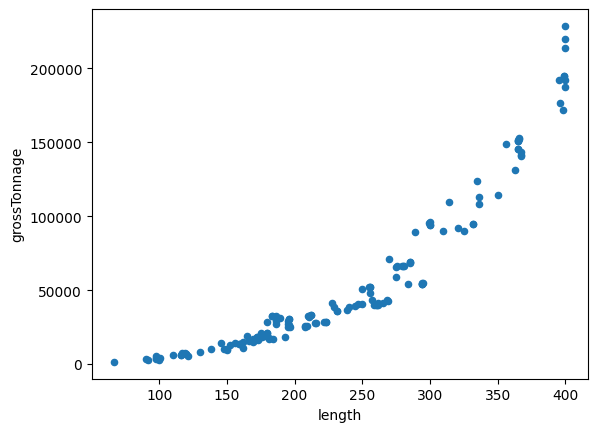

In [34]:
cs_df.plot.scatter('length','grossTonnage')

In [35]:

cs_df["length_cubed"] = cs_df["length"].apply(lambda x: x**3)

<Axes: xlabel='grossTonnage', ylabel='length_cubed'>

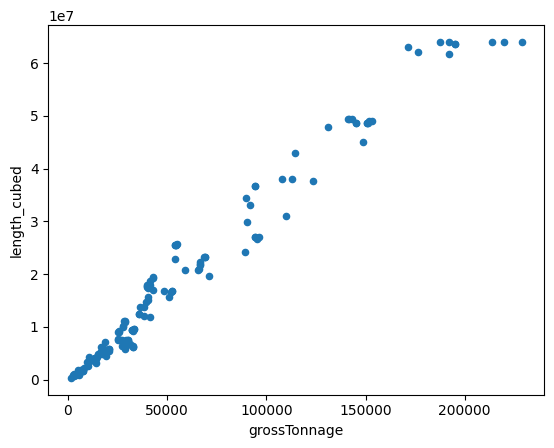

In [36]:
cs_df.plot.scatter('grossTonnage','length_cubed')

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = cs_df[['grossTonnage']] 
y = cs_df['length_cubed']

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Predict length_cubed for the test set
y_pred_cubed = model.predict(X_test)

# 5. Convert back to actual Length (meters)
predicted_length = np.cbrt(y_pred_cubed)
actual_length = np.cbrt(y_test)

In [38]:
from sklearn.metrics import mean_absolute_error, r2_score

print(f"R^2 Score: {r2_score(y_test, y_pred_cubed):.4f}")
print(f"Average Error (meters): {mean_absolute_error(actual_length, predicted_length):.2f}m")

R^2 Score: 0.9575
Average Error (meters): 10.91m


In [39]:
# The slope (m): how much length_cubed increases per 1 unit of grossTonnage
print(f"Coefficient (Slope): {model.coef_[0]}")

# The intercept (b): the value of y when grossTonnage is 0
print(f"Intercept: {model.intercept_}")

Coefficient (Slope): 334.9708956133227
Intercept: 4895.87980318442


<Axes: xlabel='length', ylabel='grossTonnage'>

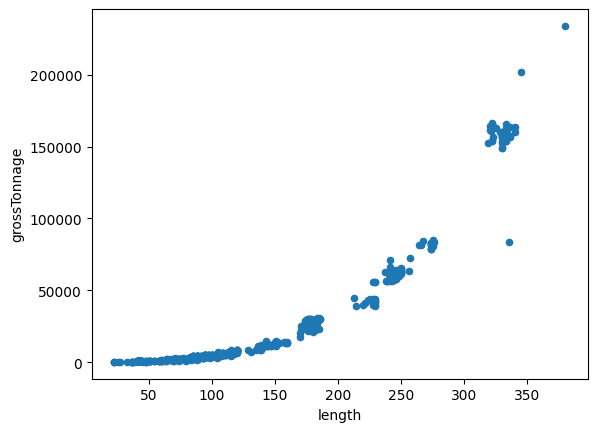

In [40]:
ta_df = df[df['type'].isin({"TA"})]
ta_df = ta_df[["imoNumber","type","length","grossTonnage"]].drop_duplicates(subset=["imoNumber"])
ta_df.plot.scatter('length','grossTonnage')

<Axes: xlabel='grossTonnage', ylabel='length_cubed'>

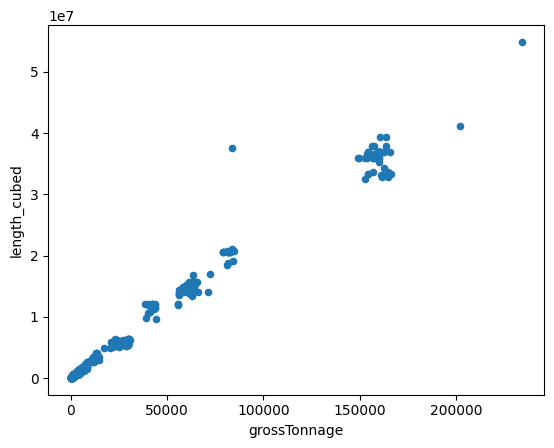

In [41]:
ta_df["length_cubed"] = ta_df["length"].apply(lambda x: x**3)
ta_df.plot.scatter('grossTonnage','length_cubed')

In [42]:
X = ta_df[['grossTonnage']] 
y = ta_df['length_cubed']

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Model
ta_model = LinearRegression()
ta_model.fit(X_train, y_train)

# 4. Predict length_cubed for the test set
y_pred_cubed = ta_model.predict(X_test)

# 5. Convert back to actual Length (meters)
predicted_length = np.cbrt(y_pred_cubed)
actual_length = np.cbrt(y_test)

In [43]:
print(f"R^2 Score: {r2_score(y_test, y_pred_cubed):.4f}")
print(f"Average Error (meters): {mean_absolute_error(actual_length, predicted_length):.2f}m")

R^2 Score: 0.9922
Average Error (meters): 8.12m


In [44]:
# The slope (m): how much length_cubed increases per 1 unit of grossTonnage
print(f"Coefficient (Slope): {ta_model.coef_[0]}")

# The intercept (b): the value of y when grossTonnage is 0
print(f"Intercept: {ta_model.intercept_}")

Coefficient (Slope): 229.10903886701644
Intercept: 83941.02773377113
